In [1]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [2]:
import os

os.environ["HF_HOME"] = "models"

In [3]:
from transformers import GPT2Model, GPT2Tokenizer

model_name = "gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2Model.from_pretrained(
    model_name,
    output_hidden_states=True
)

model = model.to(device)
model.eval()
tokenizer.pad_token = tokenizer.eos_token

print("Hidden size:", model.config.n_embd)
print("Layers:", model.config.n_layer)

/Users/armaanjagirdar/Projects/SAE_GPT2/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 14779.22it/s]


Hidden size: 768
Layers: 12


In [4]:
from datasets import load_dataset

dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train")
texts = [
    x["text"]
    for x in dataset
    if len(x["text"].strip()) > 50
]
texts = texts[:5000]

Generating validation split: 100%|██████████| 3760/3760 [00:00<00:00, 1588495.47 examples/s]


In [5]:
LAYER = 6
MAX_LENGTH = 128
BATCH_SIZE = 16

In [6]:
from tqdm.auto import tqdm

activations = []
metadata = []

with torch.no_grad():
    for i in tqdm(range(0, len(texts), BATCH_SIZE)):
        batch_texts = texts[i:i + BATCH_SIZE]

        tokens = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH
        )

        input_ids = tokens["input_ids"].to(device)
        attention_mask = tokens["attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        hidden = outputs.hidden_states[LAYER]
        mask = attention_mask.bool()

        batch_activations = hidden[mask]

        activations.append(batch_activations.detach().cpu())
        for b, text in enumerate(batch_texts):
            valid_positions = attention_mask[b].nonzero(as_tuple=True)[0]
            for pos in valid_positions:
                metadata.append({
                    "text": text,
                    "token": tokenizer.decode(input_ids[b, pos]),
                    "position": pos.item(),
                })

activations = torch.cat(activations)

100%|██████████| 313/313 [05:20<00:00,  1.02s/it]


In [7]:
mean = activations.mean(dim=0, keepdim=True)
std = activations.std(dim=0, keepdim=True) + 1e-6

activations = (activations - mean) / std
print(activations.mean().item(), activations.std().item())

-4.024822697346053e-09 0.9999985098838806


In [8]:
import torch.nn as nn
import torch.nn.functional as F

class GatedSparseAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder_gate = nn.Linear(input_dim, latent_dim)
        self.encoder_mag = nn.Linear(input_dim, latent_dim)
        self.decoder = nn.Linear(latent_dim, input_dim)

    def encode(self, x):
        pi = self.encoder_gate(x)
        gate = (pi > 0).float()
        mag = F.relu(self.encoder_mag(x))
        z = gate * mag
        return z

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        pi = self.encoder_gate(x)
        f_gate = F.relu(pi)
        gate = (pi > 0).float()

        mag = F.relu(self.encoder_mag(x))

        z = gate * mag
        x_hat = self.decoder(z)
        
        x_hat_gate = self.decoder(f_gate)

        return x_hat, z, x_hat_gate, f_gate

In [9]:
INPUT_DIM = activations.shape[1]
LATENT_DIM = 2048

torch.manual_seed(42)
sae = GatedSparseAutoencoder(input_dim=INPUT_DIM, latent_dim=LATENT_DIM).to(device)

print(sae)

GatedSparseAutoencoder(
  (encoder_gate): Linear(in_features=768, out_features=2048, bias=True)
  (encoder_mag): Linear(in_features=768, out_features=2048, bias=True)
  (decoder): Linear(in_features=2048, out_features=768, bias=True)
)


In [10]:
optimizer = torch.optim.Adam(sae.parameters(),lr=1e-3)

In [11]:
SPARSITY_COEFF = 3e-3
AUX_COEFF = 1.0
BATCH_SIZE = 512
EPOCHS = 5

for epoch in range(EPOCHS):
    permutation = torch.randperm(len(activations))

    total_loss = 0
    total_recon = 0
    total_aux = 0
    total_sparse = 0

    for i in tqdm(range(0, len(activations), BATCH_SIZE), desc=f"Epoch {epoch + 1}/{EPOCHS}"):
        indices = permutation[i:i + BATCH_SIZE]
        
        x = activations[indices].to(device)
        x_hat, z, x_hat_gate, f_gate = sae(x)

        reconstruction_loss = F.mse_loss(x_hat, x)
        aux_loss = F.mse_loss(x_hat_gate, x)
        sparsity_loss = f_gate.sum(dim=-1).mean()

        loss = (
            reconstruction_loss
            + AUX_COEFF * aux_loss
            + SPARSITY_COEFF * sparsity_loss
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            sae.decoder.weight.data = F.normalize(sae.decoder.weight.data, dim=0)

        total_loss += loss.item()
        total_recon += reconstruction_loss.item()
        total_aux += aux_loss.item()
        total_sparse += sparsity_loss.item()

    n_batches = (len(activations) + BATCH_SIZE - 1) // BATCH_SIZE

    print(
        f"loss={total_loss/n_batches:.5f} | "
        f"recon={total_recon/n_batches:.5f} | "
        f"aux={total_aux/n_batches:.5f} | "
        f"sparse={total_sparse/n_batches:.5f}"
    )

Epoch 1/5: 100%|██████████| 991/991 [00:17<00:00, 57.21it/s]


loss=0.84520 | recon=0.18185 | aux=0.36675 | sparse=98.86825


Epoch 2/5: 100%|██████████| 991/991 [00:17<00:00, 58.06it/s]


loss=0.63149 | recon=0.14835 | aux=0.25444 | sparse=76.23592


Epoch 3/5: 100%|██████████| 991/991 [00:16<00:00, 58.39it/s]


loss=0.60595 | recon=0.15659 | aux=0.23536 | sparse=71.33320


Epoch 4/5: 100%|██████████| 991/991 [00:17<00:00, 58.20it/s]


loss=0.59764 | recon=0.16497 | aux=0.22930 | sparse=67.79000


Epoch 5/5: 100%|██████████| 991/991 [00:17<00:00, 57.16it/s]

loss=0.59504 | recon=0.17240 | aux=0.22763 | sparse=65.00331


In [12]:
with torch.no_grad():
    sample = activations[:5000].to(device)
    z = sae.encode(sample)
    active_fraction = (z > 0).float().mean()
    active_per_token = (z > 0).float().sum(dim=-1).mean()

print(f"Fraction of active features: {active_fraction.item():.4%}")
print(f"Average active features per token (L0): {active_per_token.item():.2f}")

Fraction of active features: 3.4865%
Average active features per token (L0): 71.40


In [13]:
FEATURE_ID = 100

feature_activations = []

with torch.no_grad():
    z = []
    for i in range(0, len(activations), BATCH_SIZE):
        batch = activations[i:i+BATCH_SIZE].to(device)
        z_batch = sae.encode(batch)
        z.append(z_batch[:, FEATURE_ID].cpu())

feature_activations = torch.cat(z)
print(feature_activations.max().item())

11.610672950744629


In [14]:
top_k = 10

values, indices = torch.topk(feature_activations, k=top_k)

print("Top activations:")
for rank, (value, idx) in enumerate(zip(values, indices)):
    metadata_entry = metadata[idx.item()]
    print(f"\n{rank + 1:2d}. Activation={value.item():.3f}")
    print(f"Token={repr(metadata_entry['token'])}")
    print(f"Position={metadata_entry['position']}")
    print(f"Text={metadata_entry['text']}")

Top activations:

 1. Activation=11.611
Token='ow'
Position=101
Text= The final objective was Maryang San , a steep hill rising 200 metres ( 660 ft ) above the valley about 2 @,@ 500 metres ( 2 @,@ 700 yd ) north of Hill 355 . However , following the delay in capturing Hill 355 , Hassett would not be ready to implement his plan until early the next day . As such the third phase would begin on 5 October , with the Royal Northumberland Fusiliers scheduled to attack an intermediate objective — Hill 217 , adjacent Kowang @-@ San — before assisting the Australians assault Hill 317 . The Australians moved into position northeast of Hill 199 on the afternoon of 4 October , while over the night of 4 / 5 October the divisional artillery hit Chinese positions , with two batteries of 8 @-@ inch ( 200 mm ) howitzers and another two 155 @-@ millimetre ( 6 @.@ 1 in ) batteries supplementing them . Air strikes by the Mustangs of No. 2 Squadron , South African Air Force were also planned , targeting C

In [15]:
with torch.no_grad():
    sample = activations[:2000].to(device)
    z = sae.encode(sample)
    reconstructed = sae.decode(z)
    mse = F.mse_loss(reconstructed, sample)
    baseline_mse = torch.mean(activations ** 2)

print("Reconstruction MSE:", mse.item())
print("Baseline MSE:", baseline_mse.item())

Reconstruction MSE: 0.1831335872411728
Baseline MSE: 0.9999971389770508


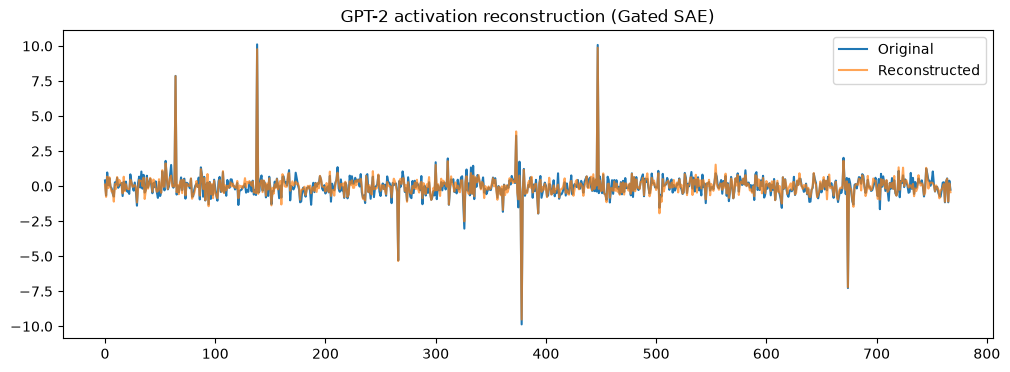

In [16]:
import matplotlib.pyplot as plt

idx = 0
original = sample[idx].cpu()
reconstructed = reconstructed[idx].cpu()

plt.figure(figsize=(12, 4))

plt.plot(original.numpy(), label="Original")
plt.plot(reconstructed.numpy(), label="Reconstructed", alpha=0.7)

plt.legend()
plt.title("GPT-2 activation reconstruction (Gated SAE)")
plt.show()

In [17]:
torch.save(sae.state_dict(), "../models/sae_trained/gated_sae.pt")
print("Saved!")

Saved!
